In [2]:
import torch


# GPU 정보 확인
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"총 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"할당된 메모리: {torch.cuda.memory_allocated() / 1e6:.1f} MB")
print(f"캐시된 메모리: {torch.cuda.memory_reserved() / 1e6:.1f} MB")


# 메모리 해제
torch.cuda.empty_cache()

GPU: NVIDIA GeForce RTX 4070
총 메모리: 12.4 GB
할당된 메모리: 0.0 MB
캐시된 메모리: 0.0 MB


In [3]:
import torch

print(torch.cuda.is_available())

def print_tensor_state(x):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(device)
    print(x.shape) # 크기
    print(x.dtype) # 데이터 타입 (float32, int64 등)
    print(x.device) # cpu 또는 cuda:0

x = torch.zeros(3, 4)
print_tensor_state(x)
x = torch.ones(3, 4)
print_tensor_state(x)
x = torch.randn(3, 4)
print_tensor_state(x)
x = torch.tensor([1, 2, 3])
print_tensor_state(x)
x = torch.arange(0, 10, 2)
print_tensor_state(x)




True
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3])
torch.int64
cuda:0
torch.Size([5])
torch.int64
cuda:0


In [4]:
a = torch.randn(3, 4)
print(f"a: {a}")
b = torch.randn(3, 4)
print(f"b: {b}")

c = a + b
print(f"c = a + b -> {c}")
c = a * b
print(f"c = a * b -> {c}")
c = a @ b.T
print(f"c = a @ b.T -> {c}")
c = torch.matmul(a, b.T)
print(f"c = torch.matmul(a, b.T) -> {c}")



a: tensor([[-1.3955, -1.9305, -0.0697, -0.1826],
        [-0.8966,  1.1182,  0.6776,  1.2557],
        [-0.1308,  0.6720, -2.2269, -0.2087]])
b: tensor([[-0.9372, -0.0557,  0.2236,  0.6137],
        [ 0.1524,  0.7485,  0.2533, -1.6578],
        [-0.2070,  1.2522, -0.8904, -1.1124]])
c = a + b -> tensor([[-2.3327, -1.9861,  0.1540,  0.4312],
        [-0.7442,  1.8667,  0.9309, -0.4021],
        [-0.3378,  1.9242, -3.1173, -1.3211]])
c = a * b -> tensor([[ 1.3078,  0.1074, -0.0156, -0.1120],
        [-0.1366,  0.8369,  0.1716, -2.0818],
        [ 0.0271,  0.8415,  1.9829,  0.2322]])
c = a @ b.T -> tensor([[ 1.2877, -1.3726, -1.8634],
        [ 1.7003, -1.2098, -0.4145],
        [-0.5410,  0.2651,  3.0836]])
c = torch.matmul(a, b.T) -> tensor([[ 1.2877, -1.3726, -1.8634],
        [ 1.7003, -1.2098, -0.4145],
        [-0.5410,  0.2651,  3.0836]])


In [5]:
x = torch.randn(2, 3, 4)
print(f"x = {x.shape}")
print(f"x.view(2, 12) -> {x.view(2, 12).shape}")        # [2,3,4] -> [2,12] (메모리 연속 필요)
print(f"x.reshape(2, 12) -> {x.reshape(2, 12).shape}")  # [2,3,4] -> [2,12] (메모리 복사 가능)
print(f"x.permute(2, 0, 1) -> {x.permute(2, 0, 1).shape}")  # [2,3,4] -> [4,2,3]

y = torch.randn(3, 4)
print(f"y.unsqueeze(0) -> {y.unsqueeze(0).shape}")      # [3,4] -> [1,3,4]

z = torch.randn(1, 3, 4)
print(f"z.squeeze(0) -> {z.squeeze(0).shape}")          # [1,3,4] -> [3,4]

x = torch.Size([2, 3, 4])
x.view(2, 12) -> torch.Size([2, 12])
x.reshape(2, 12) -> torch.Size([2, 12])
x.permute(2, 0, 1) -> torch.Size([4, 2, 3])
y.unsqueeze(0) -> torch.Size([1, 3, 4])
z.squeeze(0) -> torch.Size([3, 4])


In [6]:
import numpy as np
img_np = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0

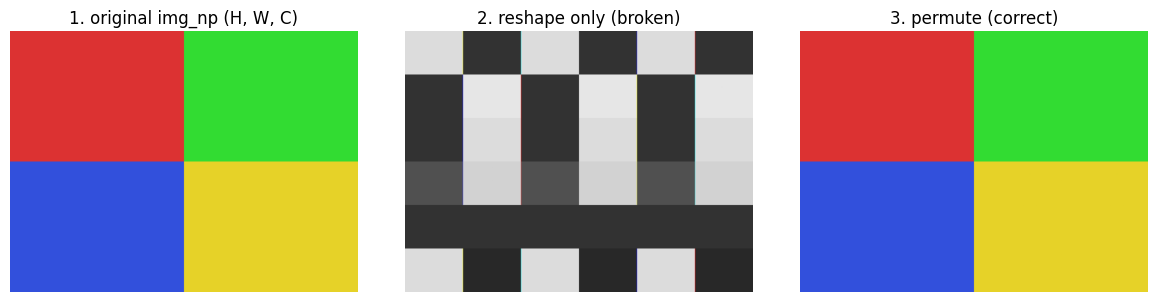

In [7]:
import matplotlib.pyplot as plt

H, W = 480, 640
img_np = np.zeros((H, W, 3), dtype=np.uint8)
img_np[: H // 2, : W // 2] = [220, 50, 50]
img_np[: H // 2, W // 2 :] = [50, 220, 50]
img_np[H // 2 :, : W // 2] = [50, 80, 220]
img_np[H // 2 :, W // 2 :] = [230, 210, 40]

img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("1. original img_np (H, W, C)")
plt.axis("off")

wrong = img_tensor.reshape(H, W, 3).cpu().numpy()
plt.subplot(1, 3, 2)
plt.imshow(wrong)
plt.title("2. reshape only (broken)")
plt.axis("off")

img_back = img_tensor.permute(1, 2, 0).cpu().numpy()
plt.subplot(1, 3, 3)
plt.imshow(img_back)
plt.title("3. permute (correct)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
import torch
x = torch.tensor([2.0, 3.0], requires_grad=True)
w = torch.tensor([1.0, -1.0], requires_grad=True)

y = x * w
loss = y.sum()

loss.backward()

print(x.grad)
print(w.grad)

tensor([ 1., -1.])
tensor([2., 3.])


In [9]:
import os

from PIL import Image
from torch.utils.data import Dataset


class ShapeDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_list = sorted(
            f for f in os.listdir(image_dir) if f.endswith(".png")
        )

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        filename = self.image_list[idx]
        img_path = os.path.join(self.image_dir, filename)
        image = Image.open(img_path).convert("RGB")
        label = int(filename.split("_")[0])

        if self.transform:
            image = self.transform(image)

        return image, label
    
datasets = ShapeDataset("./data/demo_dataset/images")
print(f"총 {len(datasets)} 장")

for dataset in datasets:
    image, label = dataset
    print(f"크기: {image.size}, 라벨: {label}")

총 60 장
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64),

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = ShapeDataset("./data/demo_dataset/images", transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=8,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

images, labels = next(iter(dataloader))
print(f"images: {images.shape}, dtype={images.dtype}")
print(f"labels: {labels.shape}, {labels.tolist()}")

for batch_idx, (images, labels) in enumerate(dataloader):
    images = images.to(device)
    labels = images.to(device)

images: torch.Size([8, 3, 64, 64]), dtype=torch.float32
labels: torch.Size([8]), [0, 0, 0, 0, 0, 0, 0, 0]


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    scheduler.step()
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] ")
    print(f"Loss: {running_loss/len(trainloader):.4f} ")
    print(f"Acc: {train_acc:.2f}%")

Epoch [1/50] 
Loss: 1.5431 
Acc: 44.16%


KeyboardInterrupt: 

In [ ]:
import torchvision.models as models

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

writer = SummaryWriter("outputs/runs/cifa10_experiment")

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

def evaluate(model, loader):
    """주어진 loader 에 대해 모델 정확도(%)를 반환. 검증/테스트용."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    scheduler.step()
    train_loss = running_loss / len(trainloader)
    train_acc = 100. * correct / total
    val_acc = evaluate(model, testloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] ")
    print(f"Loss: {train_loss:.4f} ")
    print(f"Acc: {train_acc:.2f}% ")
    print(f"Val Acc: {val_acc:.2f}%")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

Epoch [1/50] 
Loss: 1.5453 
Acc: 43.86% 
Val Acc: 47.94%
Epoch [2/50] 
Loss: 1.2283 
Acc: 56.33% 
Val Acc: 48.98%
Epoch [3/50] 
Loss: 1.1152 
Acc: 60.51% 
Val Acc: 54.68%
Epoch [4/50] 
Loss: 1.0460 
Acc: 63.09% 
Val Acc: 61.49%
Epoch [5/50] 
Loss: 0.9939 
Acc: 64.76% 
Val Acc: 51.73%
Epoch [6/50] 
Loss: 0.9530 
Acc: 66.47% 
Val Acc: 64.95%
Epoch [7/50] 
Loss: 0.9103 
Acc: 68.17% 
Val Acc: 60.72%
Epoch [8/50] 
Loss: 0.8779 
Acc: 69.50% 
Val Acc: 66.56%
Epoch [9/50] 
Loss: 0.8527 
Acc: 70.24% 
Val Acc: 67.22%
Epoch [10/50] 
Loss: 0.8275 
Acc: 71.18% 
Val Acc: 70.11%
Epoch [11/50] 
Loss: 0.7984 
Acc: 72.25% 
Val Acc: 65.75%
Epoch [12/50] 
Loss: 0.7816 
Acc: 72.79% 
Val Acc: 66.69%
Epoch [13/50] 
Loss: 0.7657 
Acc: 73.41% 
Val Acc: 69.05%
Epoch [14/50] 
Loss: 0.7460 
Acc: 74.15% 
Val Acc: 72.06%
Epoch [15/50] 
Loss: 0.7294 
Acc: 74.62% 
Val Acc: 69.83%
Epoch [16/50] 
Loss: 0.7177 
Acc: 75.14% 
Val Acc: 72.39%
Epoch [17/50] 
Loss: 0.7036 
Acc: 75.64% 
Val Acc: 73.48%
Epoch [18/50] 
Loss: 0.

In [ ]:
import torch
import numpy as np


zeros = torch.zeros(3, 4)
ones = torch.ones(2, 3)
rand = torch.randn(3, 3)
arange = torch.arange(0, 10, 2)
linspace = torch.linspace(0, 1, 5)

print(f"zeros shape: {zeros.shape}")
print(f"randn:\n{rand}")
print(f"arange: {arange}")
print(f"linspace: {linspace}")

zeros shape: torch.Size([3, 4])
randn:
tensor([[ 0.7270,  1.0792, -1.3222],
        [ 0.9395,  0.4676,  1.0209],
        [ 0.8860, -0.4361,  1.3623]])
arange: tensor([0, 2, 4, 6, 8])
linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [ ]:
np_array = np.array([[1, 2], [3, 4]], dtype=np.float32)
tensor_from_np = torch.from_numpy(np_array)
np_from_tensor = tensor_from_np.numpy()

print(f"NumPy -> Tensor: {tensor_from_np}")
print(f"Tensor -> NumPy: {np_from_tensor}")

NumPy -> Tensor: tensor([[1., 2.],
        [3., 4.]])
Tensor -> NumPy: [[1. 2.]
 [3. 4.]]


In [ ]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print(f"a + b = {a + b}")
print(f"a * b = {a * b}")
print(f"a @ b = \n{a @ b}")
print(f"a.sum() = {a.sum()}")
print(f"a.mean() = {a.mean()}")
print(f"a.max() = {a.max()}")

a + b = tensor([[ 6.,  8.],
        [10., 12.]])
a * b = tensor([[ 5., 12.],
        [21., 32.]])
a @ b = 
tensor([[19., 22.],
        [43., 50.]])
a.sum() = 10.0
a.mean() = 2.5
a.max() = 4.0


In [ ]:
x = torch.randn(3, 2, 4)
print(f"원래 shape: {x.shape}")
print(f"view(2, 12): {x.view(2, 12).shape}")
print(f"reshape(6, 4): {x.reshape(6, 4).shape}")
print(f"permute(2, 0, 1): {x.permute(2, 0, 1).shape}")
print(f"unsqueeze(0): {x.unsqueeze(0).shape}")
print(f"squeeze 후: {x.unsqueeze(0).squeeze(0).shape}")

원래 shape: torch.Size([3, 2, 4])
view(2, 12): torch.Size([2, 12])
reshape(6, 4): torch.Size([6, 4])
permute(2, 0, 1): torch.Size([4, 3, 2])
unsqueeze(0): torch.Size([1, 3, 2, 4])
squeeze 후: torch.Size([3, 2, 4])


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")
x_gpu = x.to(device)
print(f"텐서 디바이스: {x_gpu.device}")

사용 디바이스: cuda
텐서 디바이스: cuda:0


In [13]:
fake_img = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
img_tensor = torch.from_numpy(fake_img).permute(2, 0, 1).float() / 255.0
print(f"OpenCV shape: {fake_img.shape} -> PyTorch shape: {img_tensor.shape}")
print(f"dtype: {img_tensor.dtype}, range: [{img_tensor.min():.2f}, {img_tensor.max():.2f}]")

OpenCV shape: (480, 640, 3) -> PyTorch shape: torch.Size([3, 480, 640])
dtype: torch.float32, range: [0.00, 1.00]


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"디바이스: {device}")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

print(f"학습 데이터: {len(trainset)}장, 테스트 데이터 {len(testset)}장")

디바이스: cuda
학습 데이터: 50000장, 테스트 데이터 10000장


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

writer = SummaryWriter("outputs/runs/cifar10_simple_cnn")

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

num_epochs = 30
best_acc = 0.0

In [9]:
import os
os.makedirs("outputs", exist_ok=True)

print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Time':>6}")

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, trainloader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, trainloader, criterion, device
    )

    scheduler.step()
    elapsed = time.time() - start

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": epoch, 
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc,
        }, "outputs/best_cifar10_cnn.pth")
        marker = " *"
    else:
        marker = ""

    print(f"{epoch+1:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>6.2f}% | {elapsed:>5.1f}s{marker}")

writer.close()
print(f"\n최고 검증 정확도: {best_acc:.2f}%")


 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   Time
     1 |     0.9001 |    68.43% |   1.0619 |  62.58% |   4.4s
     2 |     0.8748 |    69.51% |   0.8962 |  68.40% |   4.5s *
     3 |     0.8424 |    70.52% |   0.9623 |  65.40% |   4.5s
     4 |     0.8206 |    71.27% |   0.9658 |  66.14% |   4.6s
     5 |     0.7936 |    72.30% |   0.8175 |  71.23% |   4.5s *
     6 |     0.7743 |    72.99% |   0.8044 |  71.83% |   4.6s *
     7 |     0.7550 |    73.86% |   0.8595 |  69.57% |   4.6s
     8 |     0.7376 |    74.57% |   0.7831 |  72.06% |   4.7s *
     9 |     0.7207 |    75.10% |   0.8212 |  71.09% |   4.7s
    10 |     0.7066 |    75.46% |   0.7818 |  72.60% |   4.7s *
    11 |     0.6665 |    77.06% |   0.7226 |  75.00% |   4.6s *
    12 |     0.6548 |    77.34% |   0.6419 |  78.13% |   4.7s *
    13 |     0.6475 |    77.69% |   0.7028 |  75.71% |   4.7s
    14 |     0.6416 |    77.90% |   0.6319 |  78.34% |   4.7s *
    15 |     0.6339 |    78.21% |   0.6886 |  75.82% 

In [13]:
!tensorboard --logdir=outputs/runs

/workspace/study/physical-ai-study/Studies/Phase 3/week1/.venv/lib/python3.12/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import torchvision.models as models
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])


transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)

model = models.resnet18(weights="IMAGENET1K_V1")

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

os.makedirs("outputs", exist_ok=True)
writer = SummaryWriter("outputs/runs/cifa10_resnet18")

for epoch in range(5):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss/len(trainloader):.4f}, Acc={acc:.2f}%")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

best_acc = 0.0
for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "outputs/best_resnet18_cifar10.pth")

    writer.add_scalar("Loss/train", running_loss/len(trainloader), epoch + 5)
    writer.add_scalar("Accuracy/train", train_acc, epoch + 5)
    writer.add_scalar("Accuracy/val", val_acc, epoch + 5)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%"
          + (" *" if val_acc == best_acc else ""))
    
writer.close()
print(f"\n최고 검증 정확도: {best_acc:.2f}%")

Epoch 1: Loss=0.8326, Acc=72.97%
Epoch 2: Loss=0.6213, Acc=78.73%
Epoch 3: Loss=0.5963, Acc=79.31%
Epoch 4: Loss=0.5786, Acc=80.02%
Epoch 5: Loss=0.5749, Acc=80.05%
Epoch 1: Train Acc=90.17%, Val Acc=92.70% *
Epoch 2: Train Acc=95.63%, Val Acc=93.92% *
Epoch 3: Train Acc=97.15%, Val Acc=93.90%
Epoch 4: Train Acc=98.07%, Val Acc=93.84%
Epoch 5: Train Acc=98.38%, Val Acc=94.25% *
Epoch 6: Train Acc=98.95%, Val Acc=94.83% *
Epoch 7: Train Acc=99.14%, Val Acc=95.16% *
Epoch 8: Train Acc=99.55%, Val Acc=95.50% *
Epoch 9: Train Acc=99.79%, Val Acc=95.59% *
Epoch 10: Train Acc=99.83%, Val Acc=95.89% *


KeyboardInterrupt: 

In [15]:
!tensorboard --logdir=outputs/runs

/workspace/study/physical-ai-study/Studies/Phase 3/week1/.venv/lib/python3.12/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)


In [28]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = (
    "airplain",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("outputs/best_resnet18_cifar10.pth", map_location=device))
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2434, 0.2616)),
])

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = torch.randint(0, len(testset), (10,))

for i, idx in enumerate(indices):
    image, label = testset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        prob = torch.softmax(output, dim=1)
        pred_class = prob.argmax(1).item()
        confidence = prob.max().item()

    ax = axes[i // 5, i % 5]
    img_show = image.permute(1, 2, 0).numpy()
    img_show = img_show * [0.2470, 0.2435, 0.2616] + [0.4914, 0.4822, 0.4465]
    img_show = img_show.clip(0, 1)
    ax.imshow(img_show)

    color = "green" if pred_class == label else "red"
    ax.set_title(f"Pred: {classes[pred_class]}\n"
                 f"True: {classes[label]}\n"
                 f"Conf: {confidence:.2f}",
                 color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/inference_results.png", dpi=100)